**Kết quả kiểm tra hiện tại (dataset hiện tại):**

Format: YOLO pose/keypoint
kpt_shape: [18, 3]
flip_idx: [0, 1, 5, 6, 7, 2, 3, 4, 11, 12, 13, 8, 9, 10, 15, 14, 17, 16]
names: [no_fall, fall]
train: 4308 images
valid: 1231 images
test: 616 images
CRITICAL train-valid: 0
CRITICAL train-test: 0
Bad label format/class lines: 0
Inherited geometry warnings: 0

**Mapping baseline:**


falling  -> fall

Sleeping -> fall

Sitting  -> no_fall

Standing -> no_fall

Walking  -> no_fall


**Cell 1 - Cài Thư Viện Và Kết Nối Ultralytics Platform**

Ultralytics Platform integration yêu cầu `ultralytics>=8.4.35`. Cell này để API key trực tiếp theo workflow cá nhân của bạn.

In [1]:
!pip install -q -U "ultralytics>=8.4.35"

import os

# Dán API key từ https://platform.ultralytics.com/ -> Settings -> API Keys vào đây.
ULTRALYTICS_API_KEY = "ul_8c635688e0f23f178efe154e58f35411762daf62"

if not ULTRALYTICS_API_KEY.startswith("ul_") or "DAN_API_KEY" in ULTRALYTICS_API_KEY:
    raise ValueError("Bạn chưa dán API key Ultralytics Platform thật vào Cell 1.")

os.environ["ULTRALYTICS_API_KEY"] = ULTRALYTICS_API_KEY
print("Đã cấu hình API key để stream metric train lên Ultralytics Platform.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.0 MB/s eta 0:00:00
Đã cấu hình API key để stream metric train lên Ultralytics Platform.


**Cell 2 - Import Và Cấu Hình Chính**

In [2]:
from pathlib import Path
from collections import Counter
import shutil
import zipfile
import yaml

from ultralytics import YOLO

# ===== SỬA ÍT NHẤT Ở ĐÂY =====
ZIP_FILENAME = "fall-detection-clean-fastdup-2class-sleepingFall.zip"

# Nếu attach Kaggle Dataset có tên khác, keyword vẫn nên trùng một phần tên ZIP/dataset.
DATASET_KEYWORD = "fall-detection-clean-fastdup-2class-sleepingFall"

# Để None: notebook tự tìm ZIP hoặc data.yaml trong /kaggle/input.
# Nếu đã giải nén sẵn và muốn trỏ thẳng data.yaml, điền đường dẫn tuyệt đối vào đây.
DATA_YAML_OVERRIDE = None

MODEL_NAME = "yolo11s-pose.pt" #small

# Bắt buộc sửa thành project của bạn trên Ultralytics Platform, dạng workspace/project.
# Có thể lấy chính xác giá trị này từ tab Local Training trên Platform.
PLATFORM_PROJECT = "peros/fall-detection-2"
RUN_NAME = "sleeping-as-fall-lan3"

# Dataset no-resize sẽ được YOLO resize trong lúc train.
IMG_SIZE = 960
BATCH = 8
EPOCHS = 80
PATIENCE = 15

# ===== KHÔNG SỬA NẾU KHÔNG TẠO DATASET MỚI =====
EXTRACT_ROOT = Path("/kaggle/working/dataset_2class")
CLASS_NAMES = ["no_fall", "fall"]
EXPECTED_KPT_SHAPE = [18, 3]
EXPECTED_FLIP_IDX = [0, 1, 5, 6, 7, 2, 3, 4, 11, 12, 13, 8, 9, 10, 15, 14, 17, 16]
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff", ".jfif"}

print("ZIP dataset:", ZIP_FILENAME)
print("Model:", MODEL_NAME)
print("Ultralytics Platform project:", PLATFORM_PROJECT)
print("Tên lần train:", RUN_NAME)
print("imgsz/batch/epochs:", IMG_SIZE, BATCH, EPOCHS)

if PLATFORM_PROJECT == "TEN_WORKSPACE/TEN_PROJECT" or "/" not in PLATFORM_PROJECT:
    raise ValueError("Hãy sửa PLATFORM_PROJECT thành workspace/project của bạn trước khi chạy tiếp.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ZIP dataset: fall-detection-clean-fastdup-2class-sleepingFall.zip
Model: yolo11s-pose.pt
Ultralytics Platform project: peros/fall-detection-2
Tên lần train: sleeping-as-fall-lan3
imgsz/batch/epochs: 960 8 80


**Cell 3 - Kiểm Tra GPU**

In [3]:
!nvidia-smi

Fri Jun  5 17:08:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**Cell 4 - Tìm ZIP Và Giải Nén Dataset 2 Class**

Cell này ưu tiên ZIP 2-class mới, tránh lấy nhầm dataset 5-class hoặc bản resize cũ.

In [4]:
def score_data_yaml(path: Path) -> int:
    root = path.parent
    return sum(
        int((root / split / kind).exists())
        for split in ("train", "valid", "test")
        for kind in ("images", "labels")
    )


def resolve_data_yaml() -> Path:
    if DATA_YAML_OVERRIDE is not None:
        path = Path(DATA_YAML_OVERRIDE)
        if not path.exists():
            raise FileNotFoundError(f"DATA_YAML_OVERRIDE không tồn tại: {path}")
        return path

    input_root = Path("/kaggle/input")
    zip_candidates = sorted(input_root.rglob(ZIP_FILENAME))
    print("ZIP đúng tên tìm thấy:", zip_candidates)

    if len(zip_candidates) > 1:
        raise RuntimeError(
            f"Tìm thấy nhiều ZIP tên {ZIP_FILENAME}. "
            "Hãy tháo dataset input dư hoặc đặt DATA_YAML_OVERRIDE."
        )

    if len(zip_candidates) == 1:
        if EXTRACT_ROOT.exists():
            shutil.rmtree(EXTRACT_ROOT)
        EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
        print("Tiến hành giải nén:", zip_candidates[0])
        with zipfile.ZipFile(zip_candidates[0], "r") as archive:
            archive.extractall(EXTRACT_ROOT)

        yaml_candidates = sorted(EXTRACT_ROOT.rglob("data.yaml"))
        if not yaml_candidates:
            raise FileNotFoundError("ZIP không chứa data.yaml.")
        return max(yaml_candidates, key=score_data_yaml)

    yaml_candidates = [
        path for path in sorted(input_root.rglob("data.yaml"))
        if DATASET_KEYWORD.lower() in str(path).lower()
    ]
    print("Không thấy ZIP; data.yaml matching tìm thấy:", yaml_candidates)
    if not yaml_candidates:
        raise FileNotFoundError(
            f"Không tìm thấy {ZIP_FILENAME} hoặc data.yaml khớp keyword "
            f"'{DATASET_KEYWORD}' trong /kaggle/input."
        )
    return max(yaml_candidates, key=score_data_yaml)


DATA_YAML = resolve_data_yaml()
DATASET_ROOT = DATA_YAML.parent

print("data.yaml đang dùng:", DATA_YAML)
print("Dataset root:", DATASET_ROOT)
print("Các mục trong dataset root:")
for path in sorted(DATASET_ROOT.iterdir()):
    print("-", path.name)

ZIP đúng tên tìm thấy: []
Không thấy ZIP; data.yaml matching tìm thấy: [PosixPath('/kaggle/input/datasets/nguyenhoang273/fall-detection-clean-fastdup-2class-sleepingfall/data.yaml')]
data.yaml đang dùng: /kaggle/input/datasets/nguyenhoang273/fall-detection-clean-fastdup-2class-sleepingfall/data.yaml
Dataset root: /kaggle/input/datasets/nguyenhoang273/fall-detection-clean-fastdup-2class-sleepingfall
Các mục trong dataset root:
- data.yaml
- test
- train
- valid


**Cell 5 - Xác Minh Dataset Vẫn Là YOLO Pose 2 Class**

Cell này dừng train nếu chọn nhầm dataset, thiếu label, sai `kpt_shape`, sai `flip_idx` hoặc label không còn cấu trúc pose `18 x 3`.

In [5]:
with DATA_YAML.open("r", encoding="utf-8") as handle:
    data_cfg = yaml.safe_load(handle) or {}

print("data.yaml:")
print(data_cfg)

assert int(data_cfg.get("nc", -1)) == 2, f"nc không phải 2: {data_cfg.get('nc')}"
assert list(data_cfg.get("names", [])) == CLASS_NAMES, f"names không đúng: {data_cfg.get('names')}"
assert list(data_cfg.get("kpt_shape", [])) == EXPECTED_KPT_SHAPE, (
    f"kpt_shape không đúng: {data_cfg.get('kpt_shape')}"
)
assert list(data_cfg.get("flip_idx", [])) == EXPECTED_FLIP_IDX, (
    f"flip_idx không đúng: {data_cfg.get('flip_idx')}"
)


def resolve_dataset_path(raw_path: str) -> Path:
    path = Path(str(raw_path))
    return path if path.is_absolute() else DATASET_ROOT / path


SPLIT_DIRS = {
    "train": resolve_dataset_path(data_cfg["train"]),
    "valid": resolve_dataset_path(data_cfg["val"]),
    "test": resolve_dataset_path(data_cfg["test"]),
}

expected_values = 5 + EXPECTED_KPT_SHAPE[0] * EXPECTED_KPT_SHAPE[1]
total_images = 0
all_class_counts = Counter()

for split, image_dir in SPLIT_DIRS.items():
    label_dir = image_dir.parent / "labels"
    if not image_dir.is_dir() or not label_dir.is_dir():
        raise FileNotFoundError(f"Thiếu images/labels của split {split}: {image_dir}, {label_dir}")

    image_files = sorted(
        path for path in image_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTS
    )
    label_files = sorted(label_dir.rglob("*.txt"))
    image_stems = {path.relative_to(image_dir).with_suffix("").as_posix() for path in image_files}
    label_stems = {path.relative_to(label_dir).with_suffix("").as_posix() for path in label_files}
    if image_stems != label_stems:
        raise RuntimeError(
            f"Split {split} bị lệch ảnh/label: "
            f"missing_label={len(image_stems - label_stems)}, orphan_label={len(label_stems - image_stems)}"
        )

    lengths = Counter()
    classes = Counter()
    for label_path in label_files:
        for line_number, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
            if not line.strip():
                continue
            parts = line.split()
            lengths[len(parts)] += 1
            class_id = int(float(parts[0]))
            if class_id not in (0, 1):
                raise RuntimeError(f"Class không hợp lệ: {label_path}, dòng {line_number}, class={class_id}")
            classes[class_id] += 1

    if set(lengths) != {expected_values}:
        raise RuntimeError(f"Split {split} không còn đúng YOLO pose {EXPECTED_KPT_SHAPE}: {dict(lengths)}")

    total_images += len(image_files)
    all_class_counts.update(classes)
    print(
        f"{split}: images={len(image_files)}, labels={len(label_files)}, "
        f"no_fall={classes[0]}, fall={classes[1]}, label_values={dict(lengths)}"
    )

print("Tổng ảnh:", total_images)
print("Tổng object theo class:", {CLASS_NAMES[key]: value for key, value in all_class_counts.items()})
print("PASS: dataset là YOLO Pose 2 class, có kpt_shape và flip_idx hợp lệ.")

data.yaml:
{'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'kpt_shape': [18, 3], 'flip_idx': [0, 1, 5, 6, 7, 2, 3, 4, 11, 12, 13, 8, 9, 10, 15, 14, 17, 16], 'nc': 2, 'names': ['no_fall', 'fall'], 'roboflow': {'workspace': 'my-workspace-ypuky', 'project': 'fall-detection-hxwtc-gvkbu', 'version': 7, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/my-workspace-ypuky/fall-detection-hxwtc-gvkbu/dataset/7'}}
train: images=4308, labels=4308, no_fall=3773, fall=2451, label_values={59: 6224}
valid: images=1231, labels=1231, no_fall=1271, fall=791, label_values={59: 2062}
test: images=616, labels=616, no_fall=592, fall=392, label_values={59: 984}
Tổng ảnh: 6155
Tổng object theo class: {'no_fall': 5636, 'fall': 3634}
PASS: dataset là YOLO Pose 2 class, có kpt_shape và flip_idx hợp lệ.


**Cell 6 - Train YOLO11 Pose Baseline 2 Class**

Điểm khác quan trọng so với notebook 5-class cũ:

- `CLASS_NAMES` đổi thành `no_fall`, `fall`.
- Dataset là bản không resize từ Roboflow; `imgsz=960` sẽ resize trong lúc train.
- Bật `fliplr=0.5` vì dataset mới đã có `flip_idx` swap trái-phải đúng.
- Baseline này vẫn để `Sleeping -> no_fall`; không trộn với thí nghiệm `Sleeping -> fall`.
- Truyền `project=PLATFORM_PROJECT` và `name=RUN_NAME` để Platform nhận metric của lần train.

In [6]:
# model = YOLO(MODEL_NAME)

# print("Tiến hành train YOLO11 pose baseline 2 class...")
# print("Dataset:", DATA_YAML)
# print("Ultralytics Platform project:", PLATFORM_PROJECT)
# print("Run name:", RUN_NAME)

# results = model.train(
#     data=str(DATA_YAML),
#     epochs=EPOCHS,
#     imgsz=IMG_SIZE,
#     batch=BATCH,

#     # Optimizer
#     optimizer="AdamW",
#     lr0=0.001,
#     lrf=0.01,
#     warmup_epochs=3,
#     weight_decay=0.0005,

#     # Augmentation nhẹ cho pose/action frame.
#     hsv_h=0.015,
#     hsv_s=0.5,
#     hsv_v=0.3,
#     degrees=5,
#     translate=0.05,
#     scale=0.1,
#     shear=0.0,
#     perspective=0.0,

#     # flip_idx đã được kiểm tra nên có thể bật horizontal flip.
#     fliplr=0.5,
#     flipud=0.0,

#     # Tránh augment dễ phá tư thế/ngữ cảnh fall.
#     mosaic=0.0,
#     mixup=0.0,

#     seed=42,
#     deterministic=True,

#     # Runtime
#     workers=4,
#     pretrained=True,
#     device=0,
#     cache=False,

#     # Save/log
#     save=True,
#     save_period=30,
#     plots=True,

#     # Early stopping
#     patience=PATIENCE,

#     # project dạng workspace/project để stream metric lên Ultralytics Platform.
#     project=PLATFORM_PROJECT,
#     name=RUN_NAME,
#     exist_ok=False,
#     verbose=True,
#     amp=True,
#     val=True,
# )

In [7]:
model = YOLO(MODEL_NAME)

print("Tiến hành train YOLO11 pose baseline 2 class...")
print("Dataset:", DATA_YAML)
print("Ultralytics Platform project:", PLATFORM_PROJECT)
print("Run name:", RUN_NAME)

results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,

    # Optimizer
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    warmup_epochs=3,
    weight_decay=0.0005,

    # Augmentation nhẹ cho pose/action frame.
    hsv_h=0.005,
    hsv_s=0.4,
    hsv_v=0.15,
    degrees=0.0,
    translate=0.0,
    scale=0.4,
    erasing=0.0,

    # flip_idx đã được kiểm tra nên có thể bật horizontal flip.
    fliplr=0.5,
    flipud=0.0,

    # Bật mosaic, tắt mosaic ở 10 epochs cuối
    mosaic=0.1,
    close_mosaic=10,

    seed=42,
    deterministic=True,

    # Runtime
    workers=8,
    pretrained=True,
    device=0,
    cache=True,

    # Save/log
    save=True,
    save_period=30,
    plots=True,

    # Early stopping
    patience=PATIENCE,

    # project dạng workspace/project để stream metric lên Ultralytics Platform.
    project=PLATFORM_PROJECT,
    name=RUN_NAME,
    verbose=True,
    val=True,
)

Tiến hành train YOLO11 pose baseline 2 class...
Dataset: /kaggle/input/datasets/nguyenhoang273/fall-detection-clean-fastdup-2class-sleepingfall/data.yaml
Ultralytics Platform project: peros/fall-detection-2
Run name: sleeping-as-fall-lan3
Ultralytics 8.4.60 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/nguyenhoang273/fall-detection-clean-fastdup-2class-sleepingfall/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.0, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.005, hsv_s=0.4, hsv_v=0.15, imgsz=960,

**Cell 7 - Kiểm Tra Kết Quả Train**

In [8]:
# Lấy đường dẫn output local thực tế do Ultralytics tạo sau khi train.
RUN_DIR = Path(model.trainer.save_dir)
WEIGHTS_DIR = RUN_DIR / "weights"
BEST_PT = WEIGHTS_DIR / "best.pt"
LAST_PT = WEIGHTS_DIR / "last.pt"

print("Thư mục kết quả:", RUN_DIR)
print("Có best.pt:", BEST_PT.exists(), BEST_PT)
print("Có last.pt:", LAST_PT.exists(), LAST_PT)

if not BEST_PT.exists():
    raise FileNotFoundError(f"Không tìm thấy best.pt: {BEST_PT}")

print("Các file kết quả:")
for path in sorted(RUN_DIR.iterdir()):
    print("-", path.name)

Thư mục kết quả: /kaggle/working/runs/pose/peros/fall-detection-2/sleeping-as-fall-lan3
Có best.pt: True /kaggle/working/runs/pose/peros/fall-detection-2/sleeping-as-fall-lan3/weights/best.pt
Có last.pt: True /kaggle/working/runs/pose/peros/fall-detection-2/sleeping-as-fall-lan3/weights/last.pt
Các file kết quả:
- BoxF1_curve.png
- BoxPR_curve.png
- BoxP_curve.png
- BoxR_curve.png
- PoseF1_curve.png
- PosePR_curve.png
- PoseP_curve.png
- PoseR_curve.png
- args.yaml
- confusion_matrix.png
- confusion_matrix_normalized.png
- labels.jpg
- results.csv
- results.png
- train_batch0.jpg
- train_batch1.jpg
- train_batch2.jpg
- train_batch37730.jpg
- train_batch37731.jpg
- train_batch37732.jpg
- val_batch0_labels.jpg
- val_batch0_pred.jpg
- val_batch1_labels.jpg
- val_batch1_pred.jpg
- val_batch2_labels.jpg
- val_batch2_pred.jpg
- weights


**Cell 8 - Validate Trên Test Split Bằng `best.pt`**

In [9]:
best_model = YOLO(str(BEST_PT))

print("Tiến hành validate best.pt trên test split...")
test_results = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=IMG_SIZE,
    iou=0.7,
    plots=True,
    project="/kaggle/working",
    name=f"{RUN_NAME}-test",
    exist_ok=True,
)

print("Đã validate xong test split.")

Tiến hành validate best.pt trên test split...
Ultralytics 8.4.60 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s-pose summary (fused): 110 layers, 9,936,996 parameters, 0 gradients, 23.2 GFLOPs
val: Fast image access ✅ (ping: 1.2±0.7 ms, read: 14.7±9.4 MB/s, size: 64.1 KB)
val: Scanning /kaggle/input/datasets/nguyenhoang273/fall-detection-clean-fastdup-2class-sleepingfall/test/labels... 616 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 616/616 283.9it/s 2.2s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/nguyenhoang273/fall-detection-clean-fastdup-2class-sleepingfall/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.6it/s 23.8s
                   all        616        984      0.974      0.939      0.957      0.769      0.797      0.759      0.694      0.291
               no_fall        327        592

**Cell 9 - Nén Kết Quả Để Download**

In [10]:
TRAIN_ZIP = Path("/kaggle/working") / f"{RUN_NAME}.zip"
TEST_DIR = Path("/kaggle/working") / f"{RUN_NAME}-test"
TEST_ZIP = Path("/kaggle/working") / f"{RUN_NAME}-test.zip"

print("Tiến hành nén kết quả train...")
shutil.make_archive(
    str(TRAIN_ZIP.with_suffix("")),
    "zip",
    root_dir=RUN_DIR,
)

if TEST_DIR.exists():
    print("Tiến hành nén kết quả test validation...")
    shutil.make_archive(
        str(TEST_ZIP.with_suffix("")),
        "zip",
        root_dir=TEST_DIR,
    )

print("ZIP kết quả train:", TRAIN_ZIP)
print("ZIP kết quả test:", TEST_ZIP if TEST_DIR.exists() else "Không có thư mục test validation.")

Tiến hành nén kết quả train...
Tiến hành nén kết quả test validation...
ZIP kết quả train: /kaggle/working/sleeping-as-fall-lan3.zip
ZIP kết quả test: /kaggle/working/sleeping-as-fall-lan3-test.zip


**Cell Thống Kê Dataset Đang Sử Dụng**

Cell này thống kê số ảnh và số object theo class cho từng split, sau đó vẽ biểu đồ để kiểm tra nhanh độ lệch class/split trước khi train.

Thống kê dataset đang dùng:


,split,images,objects,no_fall,fall
0,train,4308,6224,3773,2451
1,valid,1231,2062,1271,791
2,test,616,984,592,392


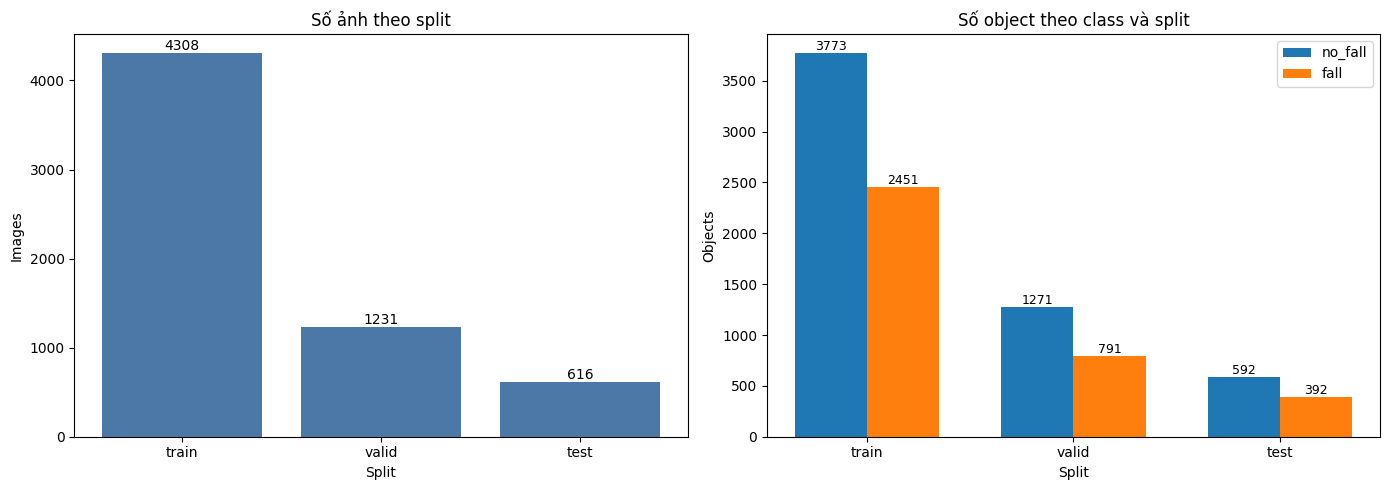

In [11]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def count_split_dataset(split: str, image_dir: Path) -> dict:
    label_dir = image_dir.parent / "labels"
    image_count = sum(
        1 for path in image_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTS
    )

    class_counts = Counter()
    object_count = 0
    for label_path in sorted(label_dir.rglob("*.txt")):
        for line in label_path.read_text(encoding="utf-8").splitlines():
            if not line.strip():
                continue
            class_id = int(float(line.split()[0]))
            class_counts[CLASS_NAMES[class_id]] += 1
            object_count += 1

    return {
        "split": split,
        "images": image_count,
        "objects": object_count,
        **{name: class_counts[name] for name in CLASS_NAMES},
    }


dataset_stats = pd.DataFrame(
    count_split_dataset(split, image_dir)
    for split, image_dir in SPLIT_DIRS.items()
)

print("Thống kê dataset đang dùng:")
display(dataset_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dataset_stats["split"], dataset_stats["images"], color="#4C78A8")
axes[0].set_title("Số ảnh theo split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Images")
for index, value in enumerate(dataset_stats["images"]):
    axes[0].text(index, value, str(value), ha="center", va="bottom")

x = np.arange(len(dataset_stats["split"]))
width = 0.35
for offset, class_name in zip((-width / 2, width / 2), CLASS_NAMES):
    axes[1].bar(x + offset, dataset_stats[class_name], width, label=class_name)
    for index, value in enumerate(dataset_stats[class_name]):
        axes[1].text(index + offset, value, str(value), ha="center", va="bottom", fontsize=9)
axes[1].set_title("Số object theo class và split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Objects")
axes[1].set_xticks(x)
axes[1].set_xticklabels(dataset_stats["split"])
axes[1].legend()

plt.tight_layout()
plt.show()


**Cell Xem Trước Ảnh Sau Augmentation**

Cell này lấy vài ảnh trong train split và áp dụng ngẫu nhiên các augmentation cùng nhóm tham số đã dùng trong `model.train(...)`: HSV, xoay nhẹ, dịch chuyển, scale và horizontal flip.


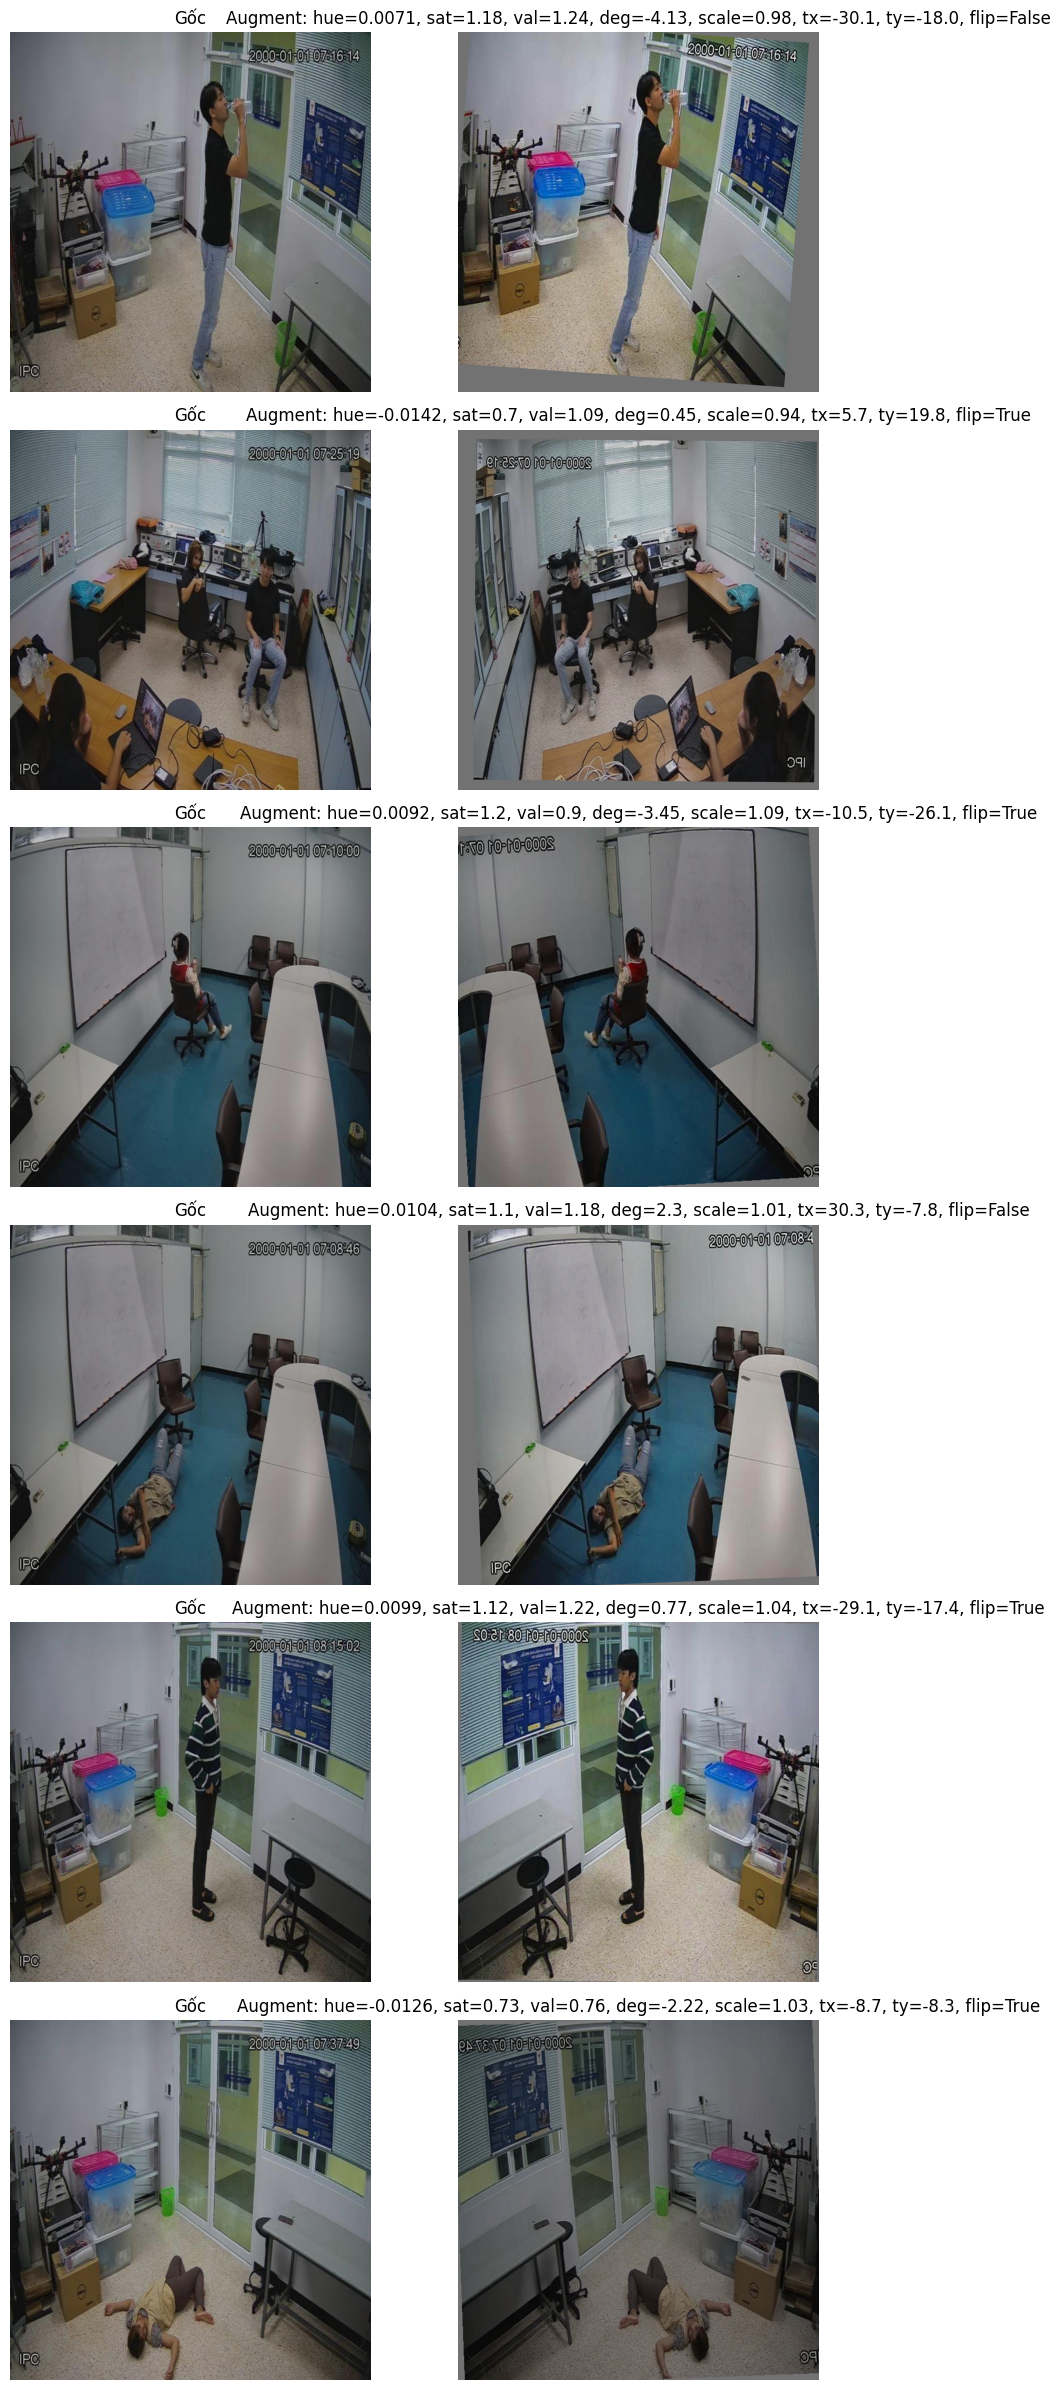

In [12]:

import random
from PIL import Image, ImageEnhance

# Giữ các tham số preview khớp với cấu hình augmentation trong cell train.
AUG_PREVIEW_CFG = {
    "hsv_h": 0.015,
    "hsv_s": 0.5,
    "hsv_v": 0.3,
    "degrees": 5,
    "translate": 0.05,
    "scale": 0.1,
    "fliplr": 0.5,
}


def apply_train_like_augmentation(image: Image.Image, cfg: dict) -> tuple[Image.Image, dict]:
    image = image.convert("RGB")
    width, height = image.size
    applied = {}

    # HSV/value jitter gần với các tham số hsv_h/hsv_s/hsv_v trong YOLO train.
    hue_shift = random.uniform(-cfg["hsv_h"], cfg["hsv_h"])
    saturation_gain = 1 + random.uniform(-cfg["hsv_s"], cfg["hsv_s"])
    value_gain = 1 + random.uniform(-cfg["hsv_v"], cfg["hsv_v"])

    hsv = image.convert("HSV")
    h, s, v = hsv.split()
    h_np = (np.array(h, dtype=np.int16) + int(hue_shift * 255)) % 255
    s_np = np.clip(np.array(s, dtype=np.float32) * saturation_gain, 0, 255).astype(np.uint8)
    v_np = np.clip(np.array(v, dtype=np.float32) * value_gain, 0, 255).astype(np.uint8)
    image = Image.merge("HSV", [Image.fromarray(h_np.astype(np.uint8)), Image.fromarray(s_np), Image.fromarray(v_np)]).convert("RGB")

    angle = random.uniform(-cfg["degrees"], cfg["degrees"])
    scale = 1 + random.uniform(-cfg["scale"], cfg["scale"])
    translate_x = random.uniform(-cfg["translate"], cfg["translate"]) * width
    translate_y = random.uniform(-cfg["translate"], cfg["translate"]) * height

    # PIL affine dùng ma trận nghịch đảo, nên chia translation theo scale để mô phỏng dịch/scale nhẹ.
    image = image.transform(
        image.size,
        Image.Transform.AFFINE,
        (1 / scale, 0, -translate_x / scale, 0, 1 / scale, -translate_y / scale),
        resample=Image.Resampling.BICUBIC,
        fillcolor=(114, 114, 114),
    )
    image = image.rotate(angle, resample=Image.Resampling.BICUBIC, fillcolor=(114, 114, 114))

    flipped = random.random() < cfg["fliplr"]
    if flipped:
        image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

    applied.update({
        "hue": round(hue_shift, 4),
        "sat": round(saturation_gain, 2),
        "val": round(value_gain, 2),
        "deg": round(angle, 2),
        "scale": round(scale, 2),
        "tx": round(translate_x, 1),
        "ty": round(translate_y, 1),
        "flip": flipped,
    })
    return image, applied


train_images = sorted(
    path for path in SPLIT_DIRS["train"].rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTS
)

sample_count = min(6, len(train_images))
if sample_count == 0:
    raise RuntimeError("Không tìm thấy ảnh trong train split để preview augmentation.")

random.seed(42)
sample_images = random.sample(train_images, sample_count)

fig, axes = plt.subplots(sample_count, 2, figsize=(10, 4 * sample_count))
if sample_count == 1:
    axes = np.array([axes])

for row, image_path in enumerate(sample_images):
    original = Image.open(image_path).convert("RGB")
    augmented, applied = apply_train_like_augmentation(original, AUG_PREVIEW_CFG)

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"Gốc")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(augmented)
    axes[row, 1].set_title("Augment: " + ", ".join(f"{k}={v}" for k, v in applied.items()))
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()
